# **Practical Session 1**

#**0. Preamble**

### **0.1. Installing packages and importing modules**

In [2]:
%%capture
! pip install matplotlib
! pip install numpy
! pip install qibo

In [3]:
from qibo    import Circuit, gates, models
from qibo.ui import plot_circuit

import logging
import matplotlib.pyplot as plt
import numpy             as np

# no timestamps
logging.getLogger("qibo").setLevel(logging.ERROR)

###**0.2. Printing and plotting function**

In [4]:
def plot_measurement_results(counts, shots, title="Measurement Results"):
    """
    Prints the measurement counts and probabilities and plots a histogram.

    Parameters
    ----------
    counts : dict
        Dictionary containing the measured states and their counts.
        Example: {'00': 512, '11': 488}
    shots : int
        Total number of shots (measurements).
    title : str, optional
        Title of the histogram.
    """

    # Print measurement results
    print("Measurement counts:\n")
    print("State | Freq  | Probability")
    print("-" * 32)

    for state, count in sorted(counts.items()):
        probability = count / shots
        print(f"{state:>5} | {count:>5} | {probability:.4f}")

    # Plot histogram
    plt.figure(figsize=(6, 4))
    plt.bar(counts.keys(), counts.values())
    plt.title(title)
    plt.xlabel("Measured State")
    plt.ylabel("Counts")
    plt.tight_layout()
    plt.show()

#**1. The Superposition and the Hadamard Gate**

In the first practice, the Hadamard gate is applied to a pure state, the basis element $|000\rangle$, in order to create an uniform superposition state. Then, the measurement is performed to obtain the statistics about the collapse in each state.

-- Hadamard gate:

$$H =
\frac{1}{\sqrt{2}}
\begin{pmatrix}
1 & 1 \\
1 & -1
\end{pmatrix}$$

-- Evolving the state in the circuit:

 $H^{⨂3} |000\rangle = \frac{1}{\sqrt{8}} (|000\rangle + |001\rangle + |010\rangle + |100\rangle + |011\rangle + |101\rangle + |110\rangle + |111\rangle)$
  
🟢 **TO DO:** Build a 3-qubits uniform superposition state by means of Hadamard Gate.

### **1.1. Visualizing the superposition**

### **EXERCICE 1:**

1. Prepare a uniform superposition state of three qubits.

2. Print the final state.

3. Measure (collapse) the final state 1024 times and evaluate the probabilities.

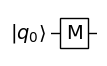

In [5]:
# step 1

q0 = Circuit(1)
q0.add(gates.M(0))

# plotting the 1-qubit circuit
plot_circuit(q0);


In [6]:
#printing the state-vector
final = q0()
print("Final state: |psi> = ", final)

[Qibo 0.3.4|INFO|2026-09-12 12:30:27]: Using numpy backend on /CPU:0
INFO:qibo.config:Using numpy backend on /CPU:0


Final state: |psi> =  (1+0j)|0>


Measurement counts:

State | Freq  | Probability
--------------------------------
    0 |  1024 | 1.0000


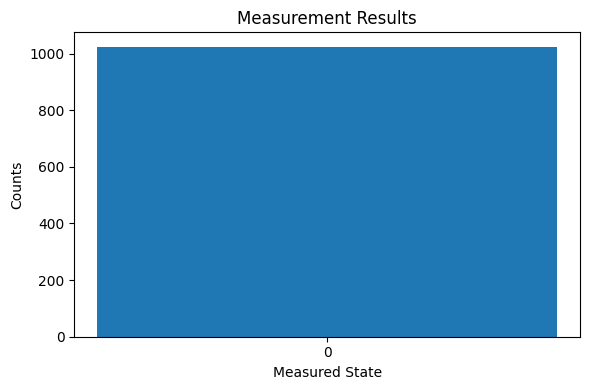

In [7]:
# measuring the final state for statistics
# nuber of measurements (shots)
shots = 1024
result = q0(nshots=shots)

# counting the results
counts = result.frequencies()

# plotting
plot_measurement_results(counts, shots)

(<Axes: >, <Figure size 120x60 with 1 Axes>)

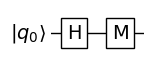

In [8]:
# step 2
#initiating the circuit
circuit0 = Circuit(1)

# applying the Hadamard gate to 1 qubit
circuit0.add(gates.H(0))

# applying the measurement gate to 1 qubit
circuit0.add(gates.M(0))

# circuit draw
plot_circuit(circuit0)

In [9]:
# printing the state vector: unifrom superposition
final_state0 = circuit0()
print("Final state: |psi> =", final_state0)

Final state: |psi> = (0.70711+0j)|0> + (0.70711+0j)|1>


Measurement counts:

State | Freq  | Probability
--------------------------------
    0 |   510 | 0.4980
    1 |   514 | 0.5020


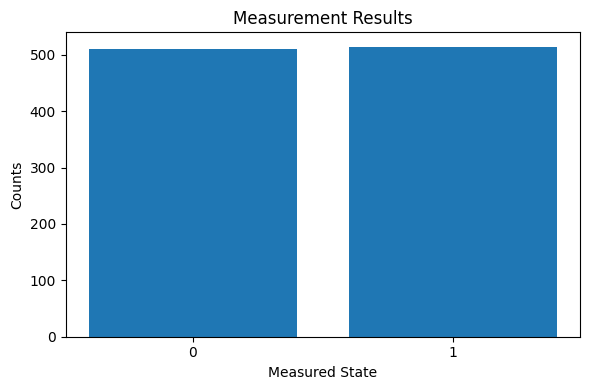

In [10]:
# number of shots
shots = 1024
result = circuit0(nshots = shots)

# counting the results
counts = result.frequencies()

# plotting
plot_measurement_results(counts, shots)

(<Axes: >, <Figure size 120x180 with 1 Axes>)

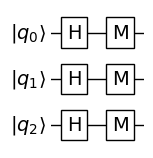

In [11]:
# step 3
# 3-qubit circuit
n = 3
uniform_superposition_circuit = Circuit(n)

# applying the Hadamard gate to all qubits
for q in range(n): uniform_superposition_circuit.add(gates.H(q))

# applying the Measurements gate to all qubits
for q in range(n): uniform_superposition_circuit.add(gates.M(q))

# circuit draw
plot_circuit(uniform_superposition_circuit)

In [12]:
#printing the final state vector
final_state1 = uniform_superposition_circuit()
print("Final state vector |psi> =", final_state1)

Final state vector |psi> = (0.35355+0j)|000> + (0.35355+0j)|001> + (0.35355+0j)|010> + (0.35355+0j)|011> + (0.35355+0j)|100> + (0.35355+0j)|101> + (0.35355+0j)|110> + (0.35355+0j)|111>


Measurement counts:

State | Freq  | Probability
--------------------------------
  000 |   135 | 0.1318
  001 |   127 | 0.1240
  010 |   131 | 0.1279
  011 |   125 | 0.1221
  100 |   121 | 0.1182
  101 |   123 | 0.1201
  110 |   137 | 0.1338
  111 |   125 | 0.1221


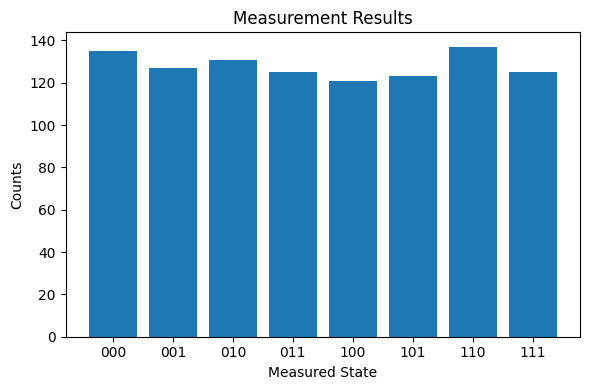

In [13]:
# number of shots
shots = 1024
result = uniform_superposition_circuit(nshots = shots)

# counting the results
counts = result.frequencies()

# plotting
plot_measurement_results(counts, shots)

#**2. The Relative Phase and the S and T Gates**

The S and T gates are single-qubit phase gates that modify the relative phase of a quantum state. These are crucial for quantum interference and constructing more complex gates, like the controlled-phase gate. In this step, these gates are applied and the statistics of the measurements is evaluated.

-- Rotation gate $R_{z}(\theta)$:
$$R_Z(\theta) =
\begin{pmatrix}
1 & 0 \\
0 & e^{i \theta}
\end{pmatrix}$$

-- $S$ gate:

$$S =
\begin{pmatrix}
1 & 0 \\
0 & i
\end{pmatrix} = R_Z(\pi / 2)$$

-- $T$ gate:

$$T =
\begin{pmatrix}
1 & 0 \\
0 & e^{i \pi/4}
\end{pmatrix} = R_Z(\pi / 4)$$



🟢 **TO DO:** Dephase the basis-states by means of S and T Gates.

### **2.1 Setting an imaginary phase by applying S Gate**

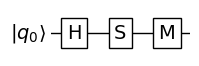

In [14]:
# circuit 2: S gate
s_gate_circuit = Circuit(1)
s_gate_circuit.add(gates.H(0))
s_gate_circuit.add(gates.S(0))
s_gate_circuit.add(gates.M(0))

# plotting the circuit
plot_circuit(s_gate_circuit);

In [15]:
# printing the final vector
final_s_gate_state = s_gate_circuit()
print("Final state: |psi> =", final_s_gate_state)

Final state: |psi> = (0.70711+0j)|0> + 0.70711j|1>


Measurement counts:

State | Freq  | Probability
--------------------------------
    0 |   500 | 0.4883
    1 |   524 | 0.5117


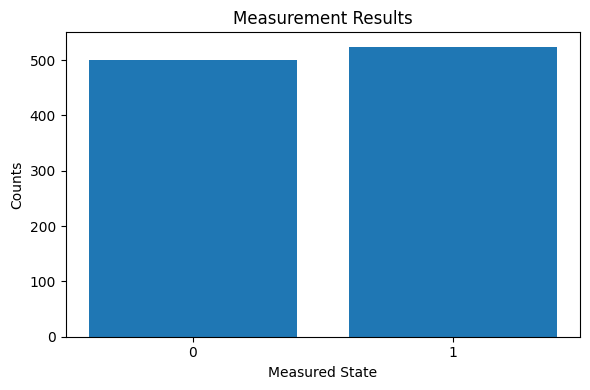

In [16]:
# shots
shots = 1024
result = s_gate_circuit(nshots=shots)

# counting the results
counts = result.frequencies()

# plotting
plot_measurement_results(counts, shots)

### **2.2 Dephasing the basis-state components**

(<Axes: >, <Figure size 240x60 with 1 Axes>)

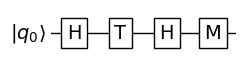

In [17]:
# T-gate
t_gate_dephasing_circuit = Circuit(1)
t_gate_dephasing_circuit.add(gates.H(0))
t_gate_dephasing_circuit.add(gates.T(0))
t_gate_dephasing_circuit.add(gates.H(0))
t_gate_dephasing_circuit.add(gates.M(0))

# drawing the circuit
plot_circuit(t_gate_dephasing_circuit)

In [18]:
# printing final state vector
final_t_gate_dephasing_state = t_gate_dephasing_circuit()
print("Final state: |psi> =", final_t_gate_dephasing_state)

Final state: |psi> = (0.85355+0.35355j)|0> + (0.14645-0.35355j)|1>


Measurement counts:

State | Freq  | Probability
--------------------------------
    0 |   886 | 0.8652
    1 |   138 | 0.1348


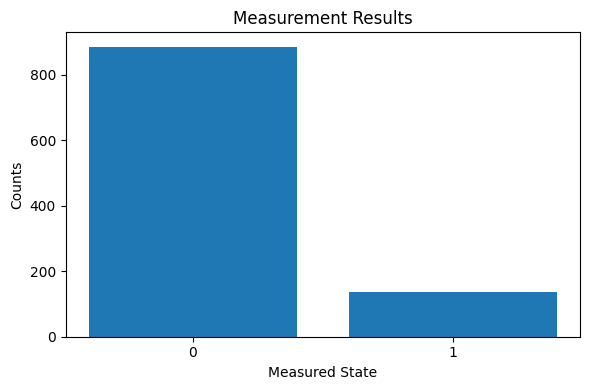

In [19]:
# number of measurements
shots = 1024
result = t_gate_dephasing_circuit(nshots=shots)

# counting the results
counts = result.frequencies()

# plotting
plot_measurement_results(counts, shots)

#**3. The Entanglement and the CNOT Gate**

To create an entangled state, the CNOT (controlled-NOT), a two-qubits gate, is applied to the qubits. The CNOT gate flips a state of a target qubit if and only if the control qubit is in state $|1\rangle$, otherwise the target remains unchanged. This gate is responsible for link both qubits.

-- Controlled-NOT gate:

$$\text{CNOT} =
\begin{pmatrix}
1 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 \\
0 & 0 & 0 & 1 \\
0 & 0 & 1 & 0
\end{pmatrix}$$

-- Evolving the state in the circuit:

$H |000\rangle = \frac{1}{\sqrt{2}} (|000\rangle + |100\rangle) = |ψ_1\rangle$

$CNOT^{1,2} |ψ_1\rangle = \frac{1}{\sqrt{2}}(|000\rangle + |110\rangle) = |ψ_2\rangle$

$CNOT^{1,3} |ψ_2\rangle = \frac{1}{\sqrt{2}}(|000\rangle + |111\rangle) = |ψ_3\rangle = |GHZ\rangle$

🟢 **TO DO:** Build the $|GHZ⟩$ state

### **3.1 The $|{\Phi^{+}}\rangle$ Bell State**

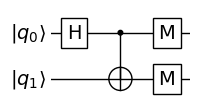

In [20]:
# phi plus state
# number of qubits
n = 2
phi_plus = Circuit(n)

# creating the superposition state
phi_plus.add(gates.H(0))

# entangling both qubits
phi_plus.add(gates.CNOT(0,1))

# applying measurements
phi_plus.add(gates.M(0))
phi_plus.add(gates.M(1))

# drawing the circuit
plot_circuit(phi_plus);

In [28]:
# printing final state vector
final_phi_plus_state = phi_plus()
print("Final state: |psi + > =", final_phi_plus_state)

Final state: |psi + > = (0.70711+0j)|00> + (-0.70711+0j)|11>


Measurement counts:

State | Freq  | Probability
--------------------------------
   00 |   523 | 0.5107
   11 |   501 | 0.4893


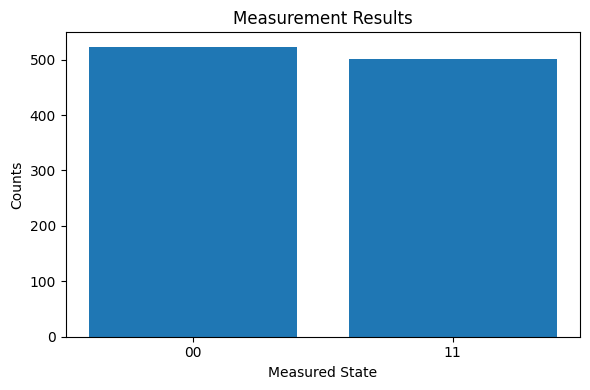

In [29]:
# number of measurements
shots = 1024
result = phi_plus(nshots=shots)

# counting the results
counts = result.frequencies()

# plotting
plot_measurement_results(counts, shots)

### **EXERCISE 2:**

Build the others Bell States:

a) $|{\Phi^{-}}\rangle$:  use Z Gate to flip the sign

b) $|{\Psi^{+}}\rangle$:  use X Gate to flip the state

c) $|{\Psi^{-}}\rangle$:  use X and Z Gates to flip the state and sign

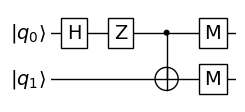

In [30]:
# item a)
# phi plus state
# number of qubits
n = 2
phi_plus = Circuit(n)

# creating the superposition state
phi_plus.add(gates.H(0))

# flipping sign
phi_plus.add(gates.Z(0))

# entangling both qubits
phi_plus.add(gates.CNOT(0,1))

# applying measurements
phi_plus.add(gates.M(0))
phi_plus.add(gates.M(1))

# drawing the circuit
plot_circuit(phi_plus);

In [24]:
# printing final state vector
final_phi_minus_state = phi_plus()
print("Final state: |psi - > =", final_phi_minus_state)

Final state: |psi - > = (0.70711+0j)|00> + (-0.70711+0j)|11>


Measurement counts:

State | Freq  | Probability
--------------------------------
   00 |   492 | 0.4805
   11 |   532 | 0.5195


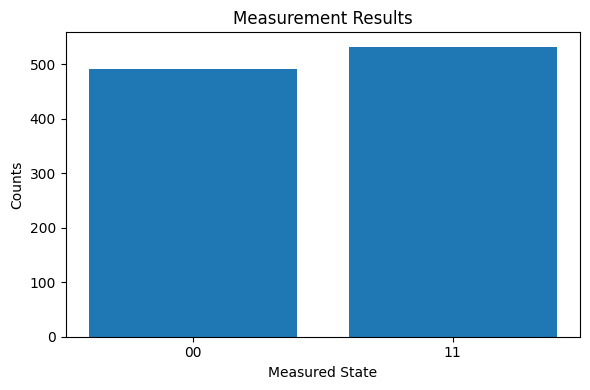

In [31]:
# number of measurements
shots = 1024
result = phi_plus(nshots=shots)

# counting the results
counts = result.frequencies()

# plotting
plot_measurement_results(counts, shots)

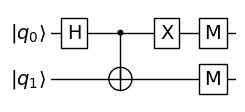

In [32]:
# item b)

# psi plus state
# number of qubits
n = 2
psi_plus = Circuit(n)

# creating the superposition state
psi_plus.add(gates.H(0))

# entangling both qubits
psi_plus.add(gates.CNOT(0,1))

psi_plus.add(gates.X(0))

# applying measurements
psi_plus.add(gates.M(0))
psi_plus.add(gates.M(1))

# drawing the circuit
plot_circuit(psi_plus);

In [33]:
# printing final state vector
final_psi_plus_state = psi_plus()
print("Final state: |psi + > =", final_psi_plus_state)

Final state: |psi + > = (0.70711+0j)|01> + (0.70711+0j)|10>


Measurement counts:

State | Freq  | Probability
--------------------------------
   01 |   551 | 0.5381
   10 |   473 | 0.4619


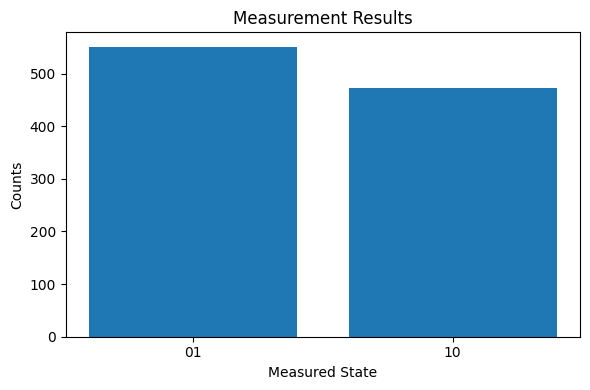

In [34]:
# number of measurements
shots = 1024
result = psi_plus(nshots=shots)

# counting the results
counts = result.frequencies()

# plotting
plot_measurement_results(counts, shots)

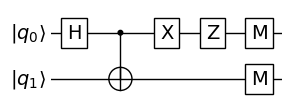

In [35]:
# item c)

# psi minus state
# number of qubits
n = 2
psi_minus = Circuit(n)

# creating the superposition state
psi_minus.add(gates.H(0))

# entangling both qubits
psi_minus.add(gates.CNOT(0,1))

psi_minus.add(gates.X(0))

psi_minus.add(gates.Z(0))

# applying measurements
psi_minus.add(gates.M(0))
psi_minus.add(gates.M(1))

# drawing the circuit
plot_circuit(psi_minus);

In [36]:
# printing final state vector
final_psi_minus_state = psi_minus()
print("Final state: |psi - > =", final_psi_minus_state)

Final state: |psi - > = (0.70711+0j)|01> + (-0.70711+0j)|10>


Measurement counts:

State | Freq  | Probability
--------------------------------
   01 |   537 | 0.5244
   10 |   487 | 0.4756


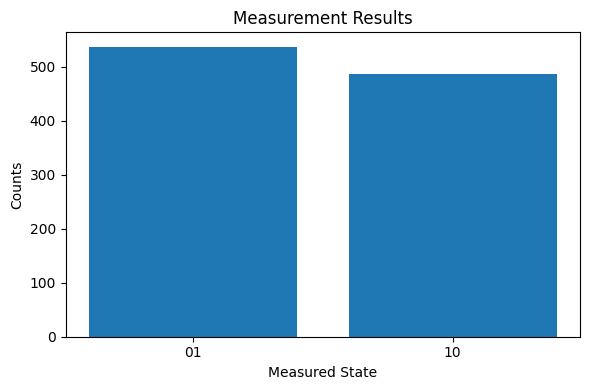

In [38]:
# number of measurements
shots = 1024
result = psi_minus(nshots=shots)

# counting the results
counts = result.frequencies()

# plotting
plot_measurement_results(counts, shots)

### **3.2 The $|GHZ⟩$ State**

(<Axes: >, <Figure size 240x180 with 1 Axes>)

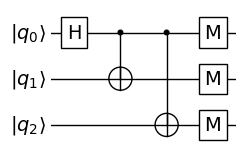

In [39]:
# number of qubits
n = 3
ghz = Circuit(n)

# creating the superposition into the 0 qubit
ghz.add(gates.H(0))

# entangling qubits 0 andd 1
ghz.add(gates.CNOT(0,1))

# entangling qubits 0 and 2
ghz.add(gates.CNOT(0,2))

# applying measurements
for q in range(n): ghz.add(gates.M(q))

# drawing the circuit
plot_circuit(ghz)

In [40]:
# printing final state vector
final_state_ghz = ghz()
print("Final state: |GHZ > =", final_state_ghz)

Final state: |GHZ > = (0.70711+0j)|000> + (0.70711+0j)|111>


Measurement counts:

State | Freq  | Probability
--------------------------------
  000 |   487 | 0.4756
  111 |   537 | 0.5244


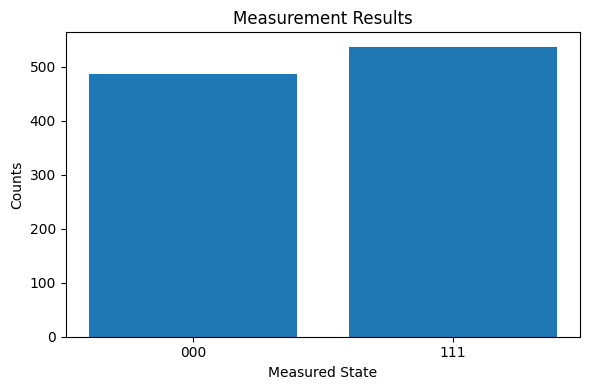

In [41]:
# number of measurements
shots = 1024
result = ghz(nshots=shots)

# counting the results
counts = result.frequencies()

# plotting
plot_measurement_results(counts, shots)

### **EXERCISE 3:**

1. Build a 3-qubit circuit using Hadamard and CNOT gates.
2. Run the circuit 1024 times.
3. Evaluate the final states and the probabilities.
4. Modify the circuit, run again, and evaluate the new final state.

(<Axes: >, <Figure size 240x180 with 1 Axes>)

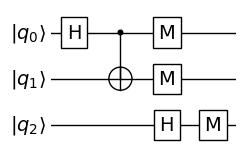

In [42]:
# step 1
# number of qubits
n = 3
three_qbit = Circuit(n)

# creating the superposition into the 0 qubit
three_qbit.add(gates.H(0))

# entangling qubits 0 andd 1
three_qbit.add(gates.CNOT(0,1))

# creating the superposition into the 2 qubit
three_qbit.add(gates.H(2))

# applying measurements
for q in range(n): three_qbit.add(gates.M(q))

# drawing the circuit
plot_circuit(three_qbit)

In [43]:
# step 2
# printing final state vector
final_state_three = three_qbit()
print("Final state: |GHZ > =", final_state_three)

Final state: |GHZ > = (0.5+0j)|000> + (0.5+0j)|001> + (0.5+0j)|110> + (0.5+0j)|111>


Measurement counts:

State | Freq  | Probability
--------------------------------
  000 |   247 | 0.2412
  001 |   232 | 0.2266
  110 |   292 | 0.2852
  111 |   253 | 0.2471


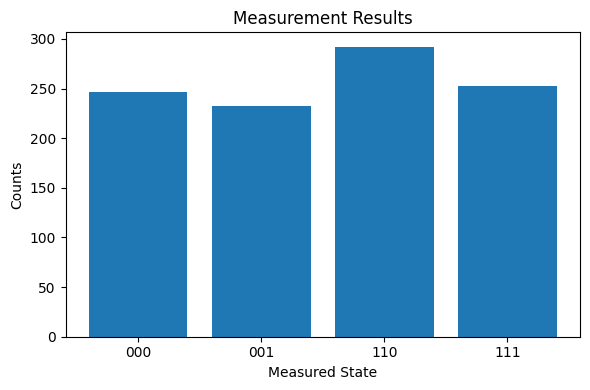

In [44]:
# step 3
# number of measurements
shots = 1024
result = three_qbit(nshots=shots)

# counting the results
counts = result.frequencies()

# plotting
plot_measurement_results(counts, shots)

(<Axes: >, <Figure size 240x180 with 1 Axes>)

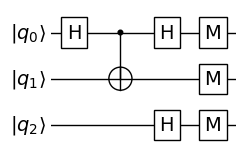

In [45]:
# step 4

# step 1
# number of qubits
n = 3
three_qbit = Circuit(n)

# creating the superposition into the 0 qubit
three_qbit.add(gates.H(0))

# entangling qubits 0 andd 1
three_qbit.add(gates.CNOT(0,1))

# creating the superposition into the 1 qubit
three_qbit.add(gates.H(0))

# creating the superposition into the 2 qubit
three_qbit.add(gates.H(2))

# applying measurements
for q in range(n): three_qbit.add(gates.M(q))

# drawing the circuit
plot_circuit(three_qbit)

In [46]:
# printing final state vector
final_state_three = three_qbit()
print("Final state: |3QUBIT> =", final_state_three)

Final state: |3QUBIT> = (0.35355+0j)|000> + (0.35355+0j)|001> + (0.35355+0j)|010> + (0.35355+0j)|011> + (0.35355+0j)|100> + (0.35355+0j)|101> + (-0.35355+0j)|110> + (-0.35355+0j)|111>


Measurement counts:

State | Freq  | Probability
--------------------------------
  000 |   127 | 0.1240
  001 |   140 | 0.1367
  010 |   119 | 0.1162
  011 |   151 | 0.1475
  100 |   123 | 0.1201
  101 |   115 | 0.1123
  110 |   126 | 0.1230
  111 |   123 | 0.1201


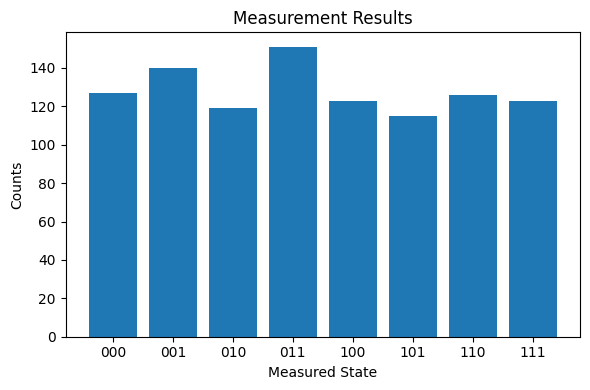

In [47]:
# number of measurements
shots = 1024
result = three_qbit(nshots=shots)

# counting the results
counts = result.frequencies()

# plotting
plot_measurement_results(counts, shots)

#**4. The Controlled Rotation Gates**

Controlled rotation gates are two-qubit controlled operations in which a single-qubit rotation is applied to the target qubit only when the control qubit is in the state $|1\rangle$. If the control qubit is in the state $|0\rangle$, the target qubit remains unchanged.

In general, a controlled rotation gate can be written as


\begin{equation}
CR_{\alpha}(\theta)
=
|0\rangle\langle0|\otimes I
+
|1\rangle\langle1|\otimes R_{\alpha}(\theta),
\qquad \alpha=x,y,z.
\end{equation}


The most commonly used controlled rotation gates are:

- Controlled-$R_{x}$ gate

\begin{equation}
CR_x(\theta)=
\begin{pmatrix}
1 & 0 & 0 & 0\\
0 & 1 & 0 & 0\\
0 & 0 & \cos\left(\frac{\theta}{2}\right) & -i\sin\left(\frac{\theta}{2}\right)\\
0 & 0 & -i\sin\left(\frac{\theta}{2}\right) & \cos\left(\frac{\theta}{2}\right)
\end{pmatrix}.
\end{equation}

- Controlled-$R_{y}$ gate

\begin{equation}
CR_y(\theta)=
\begin{pmatrix}
1 & 0 & 0 & 0\\
0 & 1 & 0 & 0\\
0 & 0 & \cos\left(\frac{\theta}{2}\right) & -\sin\left(\frac{\theta}{2}\right)\\
0 & 0 & \sin\left(\frac{\theta}{2}\right) & \cos\left(\frac{\theta}{2}\right)
\end{pmatrix}.
\end{equation}

🟢 **TO DO:** Evaluate the final state over different rotations on controlled gates

### **EXERCISE 4:**

1. Build a 2-qubits quantum circuit using Hadamard.
2. Apply the Controlled Rotation Y ($CR_y(\theta)$) or X ($CR_x(\theta)$) gates.
3. Calculate and evaluate the final state for different values of $\theta$ ($\theta = 30, 60, 90, 120, 150$).
4. Plot the histogram and compare the results for the different circuits.

#### **a) CRY($\theta = 30$)**

In [95]:
circuit_cr = Circuit(2)

for q in range(2):
  circuit_cr.add(gates.H(q))

circuit_cr.add(gates.CRY(q0 = 0, q1 = 1, theta = 30 * np.pi / 180))

# Add measurement gates for both qubits
for q in range(2): circuit_cr.add(gates.M(q))

In [96]:
# Printing final state vector
final_state_cry30 = circuit_cr()
print("Final state (CRY(30)):", final_state_cry30)

Final state (CRY(30)): (0.5+0j)|00> + (0.5+0j)|01> + (0.35355+0j)|10> + (0.61237+0j)|11>


Measurement counts:

State | Freq  | Probability
--------------------------------
   00 |   249 | 0.2432
   01 |   256 | 0.2500
   10 |   132 | 0.1289
   11 |   387 | 0.3779


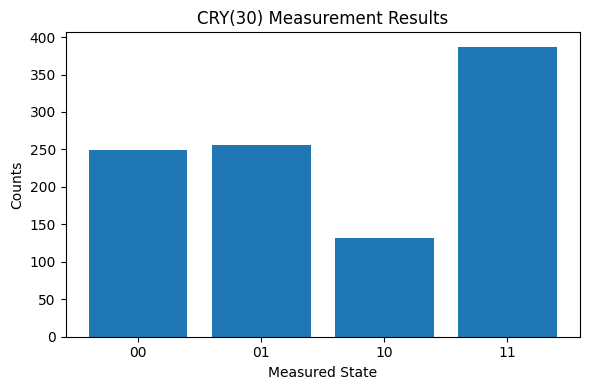

In [97]:
# Number of measurements
shots = 1024
result = circuit_cr(nshots=shots)

# Counting the results
counts = result.frequencies()

# Plotting
plot_measurement_results(counts, shots, title="CRY(30) Measurement Results")

#### **b) CRX($\theta = 60$)**

In [98]:
circuit_cr = Circuit(2)

for q in range(2):
  circuit_cr.add(gates.H(q))

circuit_cr.add(gates.CRY(q0 = 0, q1 = 1, theta = 60 * np.pi / 180))

# Add measurement gates for both qubits
for q in range(2): circuit_cr.add(gates.M(q))

In [99]:
# Printing final state vector
final_state_cry60 = circuit_cr()
print("Final state (CRY(60)):", final_state_cry60)

Final state (CRY(60)): (0.5+0j)|00> + (0.5+0j)|01> + (0.18301+0j)|10> + (0.68301+0j)|11>


Measurement counts:

State | Freq  | Probability
--------------------------------
   00 |   244 | 0.2383
   01 |   253 | 0.2471
   10 |    34 | 0.0332
   11 |   493 | 0.4814


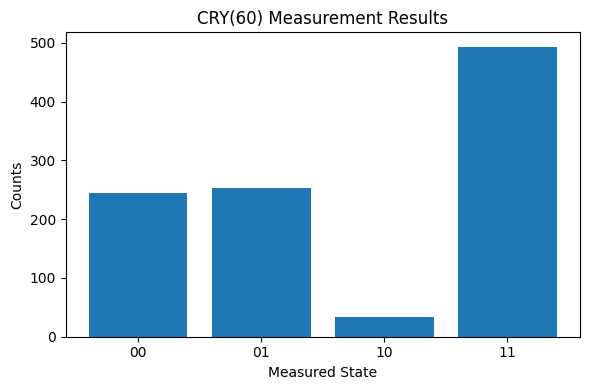

In [100]:
# Number of measurements
shots = 1024
result = circuit_cr(nshots=shots)

# Counting the results
counts = result.frequencies()

# Plotting
plot_measurement_results(counts, shots, title="CRY(60) Measurement Results")

#### **c) CRY($\theta = 90$) and CRX($\theta = 90$)**

In [101]:
circuit_cr = Circuit(2)

for q in range(2):
  circuit_cr.add(gates.H(q))

circuit_cr.add(gates.CRY(q0 = 1, q1 = 0, theta = 90 * np.pi / 180))
circuit_cr.add(gates.CRX(q0 = 0, q1 = 1, theta = 90 * np.pi / 180))

# Add measurement gates for both qubits
for q in range(2): circuit_cr.add(gates.M(q))

In [102]:
# Printing final state vector
final_state_crycrx90 = circuit_cr()
print("Final state (CRY(90)+CRX(90)):", final_state_crycrx90)

Final state (CRY(90)+CRX(90)): (0.5+0j)|00> + (0.35355-0.5j)|10> + (0.5-0.35355j)|11>


Measurement counts:

State | Freq  | Probability
--------------------------------
   00 |   263 | 0.2568
   10 |   370 | 0.3613
   11 |   391 | 0.3818


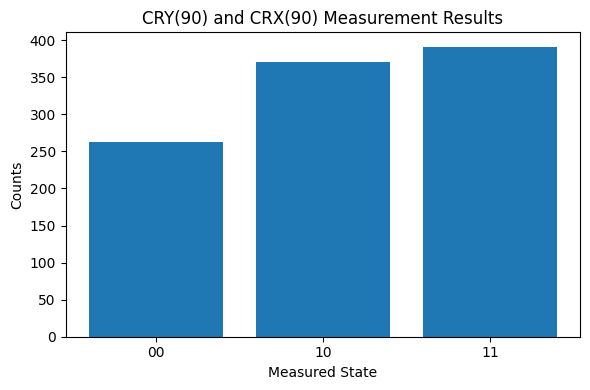

In [103]:
# Number of measurements
shots = 1024
result = circuit_cr(nshots=shots)

# Counting the results
counts = result.frequencies()

# Plotting
plot_measurement_results(counts, shots, title="CRY(90) and CRX(90) Measurement Results")

#### **d) CRX($\theta = 120$) and CRY($\theta = 120$)**

In [104]:
circuit_cr = Circuit(2)

for q in range(2):
  circuit_cr.add(gates.H(q))

circuit_cr.add(gates.CRY(q0 = 1, q1 = 0, theta = 120 * np.pi / 180))
circuit_cr.add(gates.CRX(q0 = 0, q1 = 1, theta = 120 * np.pi / 180))

# Add measurement gates for both qubits
for q in range(2): circuit_cr.add(gates.M(q))

In [105]:
# Printing final state vector
final_state_crycrx120 = circuit_cr()
print("Final state (CRY(120)+CRX(120)):", final_state_crycrx120)

Final state (CRY(120)+CRX(120)): (0.5+0j)|00> + (-0.18301+0j)|01> + (0.25-0.59151j)|10> + (0.34151-0.43301j)|11>


Measurement counts:

State | Freq  | Probability
--------------------------------
   00 |   259 | 0.2529
   01 |    44 | 0.0430
   10 |   427 | 0.4170
   11 |   294 | 0.2871


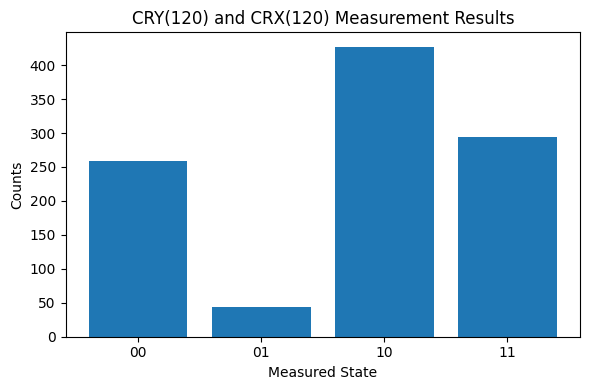

In [106]:
# Number of measurements
shots = 1024
result = circuit_cr(nshots=shots)

# Counting the results
counts = result.frequencies()

# Plotting
plot_measurement_results(counts, shots, title="CRY(120) and CRX(120) Measurement Results")

#### **e) CRX($\theta = 150$) and CRY($\theta = 150$) and CRX($\theta = 150$)**

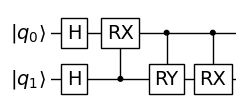

In [107]:
circuit_cr = Circuit(2)

for q in range(2):
  circuit_cr.add(gates.H(q))

circuit_cr.add(gates.CRX(q0 = 1, q1 = 0, theta = 150 * np.pi / 180))
circuit_cr.add(gates.CRY(q0 = 0, q1 = 1, theta = 150 * np.pi / 180))
circuit_cr.add(gates.CRX(q0 = 0, q1 = 1, theta = 150 * np.pi / 180))
plot_circuit(circuit_cr)

# Add measurement gates for both qubits
for q in range(2): circuit_cr.add(gates.M(q))

In [108]:
# Printing final state vector
final_state_crx_cry_crx150 = circuit_cr()
print("Final state (CRX(150)+CRY(150)+CRX(150)):", final_state_crx_cry_crx150)

Final state (CRX(150)+CRY(150)+CRX(150)): (0.5+0j)|00> + (0.12941-0.48296j)|01> + (-0.1196-0.37812j)|10> + (0.58428-0.03661j)|11>


Measurement counts:

State | Freq  | Probability
--------------------------------
   00 |   246 | 0.2402
   01 |   260 | 0.2539
   10 |   188 | 0.1836
   11 |   330 | 0.3223


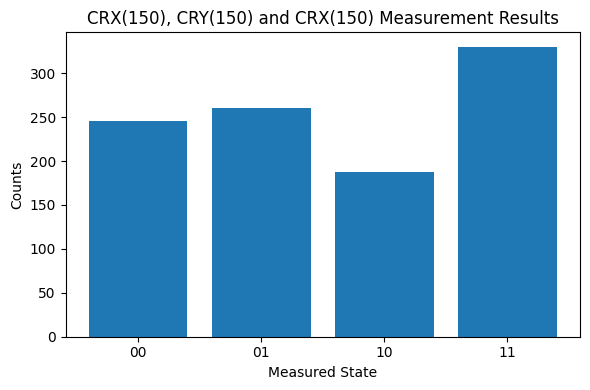

In [109]:
# Number of measurements
shots = 1024
result = circuit_cr(nshots=shots)

# Counting the results
counts = result.frequencies()

# Plotting
plot_measurement_results(counts, shots, title="CRX(150), CRY(150) and CRX(150) Measurement Results")